# Import packages, set directories and options

In [15]:
# Make local editable packages automatically reload

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [16]:
# Import dependencies

import numpy as np
import pandas as pd
import os
from code_modules import DirectoryManager as dm
from code_modules import VideoSegmentation_01_utils as omnu
from code_modules import TrackAnalysis_03_utils as tu
from code_modules import SegmentationAnalysis_02_utils as sau

In [17]:
# Set working directory

folder_manager = dm.directory_manager()
print(folder_manager.tracksdir)

/Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/tracks


# Load tracks and clean up dataframes and display

In [18]:
# Set pixel scale and frame interval, metadata from the image acquisition

pixel_scale = 0.065 #micron/pixel
frame_interval = 5 #sec

In [19]:
# Load csv files saved from TrackMate, make sure to save the spot file with a name ending with "_spots.csv"

dataframes = tu.load_csv_files_with_spots(folder_manager.tracksdir)

Loaded 241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_mix10pc_1h_3-CH1_spots.csv with utf-8 encoding
Loaded 240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h_5-CH1_spots.csv with utf-8 encoding
Loaded 240917_459+2624_0p55pagarose_2xTrpNC_OD0p5_mix10pc_5s_2h55_6-CH1_spots.csv with utf-8 encoding
Loaded 241004_177+2618_0p5pagarose_2xTrpNC_OD0p5_5s_1h_5005-CH1_spots.csv with utf-8 encoding
Loaded 240917_177+2618_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h30_1001-CH1_spots.csv with utf-8 encoding
Loaded 240917_177+2618_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_2h55_7-CH1_spots.csv with utf-8 encoding
Loaded 240913_232+2621_0p55agarose_2xTrpNC_OD0p5_mix10pc_5s_2h_6001-CH1_spots.csv with utf-8 encoding


In [20]:
# Clean all loaded CSV DataFrames, removing unnecessary rows and columns, and preparing them for analysis
# Display number of unique tracks per dataframe

cleaned_dataframes=tu.clean_all_csv(dataframes)
unique_track_counts = tu.count_unique_tracks_all(cleaned_dataframes)
tu.display_all_tracks(cleaned_dataframes, all=False)

Number of unique tracks in 241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_mix10pc_1h_3-CH1_spots.csv: 98
Number of unique tracks in 240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h_5-CH1_spots.csv: 42
Number of unique tracks in 240917_459+2624_0p55pagarose_2xTrpNC_OD0p5_mix10pc_5s_2h55_6-CH1_spots.csv: 159
Number of unique tracks in 241004_177+2618_0p5pagarose_2xTrpNC_OD0p5_5s_1h_5005-CH1_spots.csv: 220
Number of unique tracks in 240917_177+2618_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h30_1001-CH1_spots.csv: 84
Number of unique tracks in 240917_177+2618_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_2h55_7-CH1_spots.csv: 230
Number of unique tracks in 240913_232+2621_0p55agarose_2xTrpNC_OD0p5_mix10pc_5s_2h_6001-CH1_spots.csv: 364
Displaying data from 241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_mix10pc_1h_3-CH1_spots.csv:


,SPOT_ID,TRACK_ID,POSITION_X,POSITION_Y,FRAME,ELLIPSE_MAJOR,ELLIPSE_MINOR,ELLIPSE_THETA,ELLIPSE_ASPECTRATIO,AREA
0,4113,0,8.167664,20.349733,0,2.220297,0.442862,2.558507,5.013519,3.075800
1,4750,0,7.832383,20.798001,1,2.309131,0.448002,-0.426129,5.154283,3.113825
2,3236,0,8.358747,20.687845,2,2.276152,0.460641,2.883941,4.941274,3.113825
3,4073,0,9.110057,20.718630,3,2.295258,0.451126,-0.124465,5.087838,3.124388
4,3363,0,9.697958,20.712395,4,2.289510,0.477515,-0.116845,4.794631,3.145513
...,...,...,...,...,...,...,...,...,...,...
4508,45215,124,92.657668,56.190119,55,1.566581,0.470750,0.300016,3.327839,2.209675
4509,51553,124,92.708581,56.852654,56,1.639720,0.450854,0.136144,3.636921,2.186438
4510,51318,124,94.180746,57.030350,57,3.046513,0.472295,0.167793,6.450449,4.301050
4511,51503,124,93.114344,56.839207,58,1.632292,0.475623,0.236916,3.431905,2.237138


Displaying data from 240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h_5-CH1_spots.csv:


,SPOT_ID,TRACK_ID,POSITION_X,POSITION_Y,FRAME,ELLIPSE_MAJOR,ELLIPSE_MINOR,ELLIPSE_THETA,ELLIPSE_ASPECTRATIO,AREA
0,6858,0,82.944561,86.727634,0,2.005995,0.514414,1.519430,3.899574,2.860325
1,7912,0,82.967711,87.293697,1,2.106271,0.466557,1.511367,4.514502,2.915250
2,7697,0,82.967462,87.298590,2,2.042450,0.461009,1.497517,4.430387,2.843425
3,7500,0,82.989287,87.366422,3,2.079337,0.454126,1.527320,4.578769,2.832863
4,7398,0,82.960228,87.412688,4,2.049034,0.473618,1.556880,4.326339,2.815963
...,...,...,...,...,...,...,...,...,...,...
1789,36084,40,66.200385,115.807460,57,2.679897,0.456546,-0.726573,5.869941,3.722225
1790,35896,40,66.509398,115.582737,58,2.650675,0.481196,-0.720114,5.508510,3.775038
1791,36071,40,66.875234,115.269724,59,2.672642,0.487518,2.517536,5.482138,3.772925
1792,36028,41,95.949586,129.566467,58,2.853252,0.437012,1.629551,6.529002,3.779263


Displaying data from 240917_459+2624_0p55pagarose_2xTrpNC_OD0p5_mix10pc_5s_2h55_6-CH1_spots.csv:


...

,SPOT_ID,TRACK_ID,POSITION_X,POSITION_Y,FRAME,ELLIPSE_MAJOR,ELLIPSE_MINOR,ELLIPSE_THETA,ELLIPSE_ASPECTRATIO,AREA
0,6154,0,41.133607,38.923831,0,1.098089,0.605714,-0.318110,1.812882,2.042788
1,5690,0,41.174564,38.941964,1,1.087810,0.600933,-0.327402,1.810203,2.011100
2,6103,0,41.190395,38.942530,2,1.084298,0.597322,-0.341232,1.815264,2.008988
3,6048,0,41.206770,38.954267,3,1.086804,0.609627,-0.307113,1.782736,2.040675
4,5598,0,41.236423,38.964382,4,1.092904,0.601656,-0.301201,1.816493,2.011100
...,...,...,...,...,...,...,...,...,...,...
3868,53747,162,124.547035,109.160798,57,2.151084,0.535305,2.618483,4.018427,3.578575
3869,53709,162,124.605050,109.118505,58,2.181204,0.554426,2.652785,3.934164,3.646175
3870,53691,162,124.702386,109.097708,59,2.170439,0.556953,2.696458,3.896989,3.629275
3871,12859,163,124.941915,111.877707,2,1.876516,0.561991,0.048408,3.339050,3.175088


Displaying data from 240917_177+2618_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_2h55_7-CH1_spots.csv:


,SPOT_ID,TRACK_ID,POSITION_X,POSITION_Y,FRAME,ELLIPSE_MAJOR,ELLIPSE_MINOR,ELLIPSE_THETA,ELLIPSE_ASPECTRATIO,AREA
0,65578,0,17.590099,105.406512,0,1.470993,0.474108,1.995476,3.102657,2.108275
1,74126,0,18.043202,104.170025,1,1.487822,0.481498,2.039589,3.089983,2.087150
2,64363,0,18.205122,102.987993,2,1.422948,0.494845,1.931274,2.875542,2.131513
3,65721,0,19.457615,102.349128,3,1.469345,0.503559,2.732297,2.917922,2.148413
4,65473,0,20.805186,101.503787,4,1.491709,0.462841,2.545431,3.222941,2.082925
...,...,...,...,...,...,...,...,...,...,...
7600,301156,273,28.620215,17.854646,55,1.901049,0.465666,2.027805,4.082431,2.615275
7601,349885,273,29.066004,17.248875,56,1.841590,0.438625,-0.744861,4.198556,2.425150
7602,349759,273,28.247667,17.327166,57,1.807200,0.455016,2.080923,3.971731,2.560350
7603,349960,273,28.524044,16.452610,58,1.829286,0.462065,2.312420,3.958934,2.598375


Displaying data from 240913_232+2621_0p55agarose_2xTrpNC_OD0p5_mix10pc_5s_2h_6001-CH1_spots.csv:


,SPOT_ID,TRACK_ID,POSITION_X,POSITION_Y,FRAME,ELLIPSE_MAJOR,ELLIPSE_MINOR,ELLIPSE_THETA,ELLIPSE_ASPECTRATIO,AREA
0,16387,0,75.933262,92.854699,0,2.000837,0.404744,1.824884,4.943460,2.393462
1,16776,0,76.144878,92.260042,1,1.973037,0.410875,-1.345697,4.802041,2.461063
2,16723,0,76.161833,92.886625,2,2.069116,0.400537,-1.387809,5.165847,2.465288
3,45963,0,76.062022,94.508108,3,1.900504,0.432679,-1.386636,4.392407,2.503312
4,57124,0,76.224064,95.200179,4,1.942795,0.406144,-1.407771,4.783509,2.473737
...,...,...,...,...,...,...,...,...,...,...
14514,186896,597,4.919984,70.955806,55,1.996353,0.442031,2.890748,4.516318,2.661750
14515,184761,597,4.973031,70.989572,56,2.024259,0.454035,2.997266,4.458372,2.756812
14516,191283,597,4.282321,71.018101,57,2.032484,0.446688,-0.194464,4.550123,2.786387
14517,192568,597,3.751386,70.692108,58,1.914585,0.510212,2.744890,3.752527,2.870888


In [21]:
# Separate splitting tracks

split_dataframes=tu.reindex_split_tracks_all(cleaned_dataframes,track_ids=[],exclude=[])
unique_track_counts = tu.count_unique_tracks_all(split_dataframes)
tu.display_all_tracks(split_dataframes, all=False)

Processing 241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_mix10pc_1h_3-CH1_spots.csv
Processing 240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h_5-CH1_spots.csv
Processing 240917_459+2624_0p55pagarose_2xTrpNC_OD0p5_mix10pc_5s_2h55_6-CH1_spots.csv
Processing 241004_177+2618_0p5pagarose_2xTrpNC_OD0p5_5s_1h_5005-CH1_spots.csv
Processing 240917_177+2618_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h30_1001-CH1_spots.csv
Processing 240917_177+2618_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_2h55_7-CH1_spots.csv
Processing 240913_232+2621_0p55agarose_2xTrpNC_OD0p5_mix10pc_5s_2h_6001-CH1_spots.csv
Number of unique tracks in 241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_mix10pc_1h_3-CH1_spots.csv: 98
Number of unique tracks in 240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h_5-CH1_spots.csv: 42
Number of unique tracks in 240917_459+2624_0p55pagarose_2xTrpNC_OD0p5_mix10pc_5s_2h55_6-CH1_spots.csv: 159
Number of unique tracks in 241004_177+2618_0p5pagarose_2xTrpNC_OD0p5_5s_1h_5005-CH1_spots.csv: 234

,SPOT_ID,TRACK_ID,PREV_TRACK_ID,POSITION_X,POSITION_Y,FRAME,ELLIPSE_MAJOR,ELLIPSE_MINOR,ELLIPSE_THETA,ELLIPSE_ASPECTRATIO,AREA
0,4113,0,,8.167664,20.349733,0,2.220297,0.442862,2.558507,5.013519,3.075800
1,4750,0,,7.832383,20.798001,1,2.309131,0.448002,-0.426129,5.154283,3.113825
2,3236,0,,8.358747,20.687845,2,2.276152,0.460641,2.883941,4.941274,3.113825
3,4073,0,,9.110057,20.718630,3,2.295258,0.451126,-0.124465,5.087838,3.124388
4,3363,0,,9.697958,20.712395,4,2.289510,0.477515,-0.116845,4.794631,3.145513
...,...,...,...,...,...,...,...,...,...,...,...
4508,45215,124,,92.657668,56.190119,55,1.566581,0.470750,0.300016,3.327839,2.209675
4509,51553,124,,92.708581,56.852654,56,1.639720,0.450854,0.136144,3.636921,2.186438
4510,51318,124,,94.180746,57.030350,57,3.046513,0.472295,0.167793,6.450449,4.301050
4511,51503,124,,93.114344,56.839207,58,1.632292,0.475623,0.236916,3.431905,2.237138


Displaying data from 240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h_5-CH1_spots.csv:


,SPOT_ID,TRACK_ID,PREV_TRACK_ID,POSITION_X,POSITION_Y,FRAME,ELLIPSE_MAJOR,ELLIPSE_MINOR,ELLIPSE_THETA,ELLIPSE_ASPECTRATIO,AREA
0,6858,0,,82.944561,86.727634,0,2.005995,0.514414,1.519430,3.899574,2.860325
1,7912,0,,82.967711,87.293697,1,2.106271,0.466557,1.511367,4.514502,2.915250
2,7697,0,,82.967462,87.298590,2,2.042450,0.461009,1.497517,4.430387,2.843425
3,7500,0,,82.989287,87.366422,3,2.079337,0.454126,1.527320,4.578769,2.832863
4,7398,0,,82.960228,87.412688,4,2.049034,0.473618,1.556880,4.326339,2.815963
...,...,...,...,...,...,...,...,...,...,...,...
1789,36084,40,,66.200385,115.807460,57,2.679897,0.456546,-0.726573,5.869941,3.722225
1790,35896,40,,66.509398,115.582737,58,2.650675,0.481196,-0.720114,5.508510,3.775038
1791,36071,40,,66.875234,115.269724,59,2.672642,0.487518,2.517536,5.482138,3.772925
1792,36028,41,,95.949586,129.566467,58,2.853252,0.437012,1.629551,6.529002,3.779263


Displaying data from 240917_459+2624_0p55pagarose_2xTrpNC_OD0p5_mix10pc_5s_2h55_6-CH1_spots.csv:


...

,SPOT_ID,TRACK_ID,PREV_TRACK_ID,POSITION_X,POSITION_Y,FRAME,ELLIPSE_MAJOR,ELLIPSE_MINOR,ELLIPSE_THETA,ELLIPSE_ASPECTRATIO,AREA
0,6154,0,,41.133607,38.923831,0,1.098089,0.605714,-0.318110,1.812882,2.042788
1,5690,0,,41.174564,38.941964,1,1.087810,0.600933,-0.327402,1.810203,2.011100
2,6103,0,,41.190395,38.942530,2,1.084298,0.597322,-0.341232,1.815264,2.008988
3,6048,0,,41.206770,38.954267,3,1.086804,0.609627,-0.307113,1.782736,2.040675
4,5598,0,,41.236423,38.964382,4,1.092904,0.601656,-0.301201,1.816493,2.011100
...,...,...,...,...,...,...,...,...,...,...,...
3868,53747,162,,124.547035,109.160798,57,2.151084,0.535305,2.618483,4.018427,3.578575
3869,53709,162,,124.605050,109.118505,58,2.181204,0.554426,2.652785,3.934164,3.646175
3870,53691,162,,124.702386,109.097708,59,2.170439,0.556953,2.696458,3.896989,3.629275
3871,12859,163,,124.941915,111.877707,2,1.876516,0.561991,0.048408,3.339050,3.175088


Displaying data from 240917_177+2618_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_2h55_7-CH1_spots.csv:


,SPOT_ID,TRACK_ID,PREV_TRACK_ID,POSITION_X,POSITION_Y,FRAME,ELLIPSE_MAJOR,ELLIPSE_MINOR,ELLIPSE_THETA,ELLIPSE_ASPECTRATIO,AREA
0,65578,0,,17.590099,105.406512,0,1.470993,0.474108,1.995476,3.102657,2.108275
1,74126,0,,18.043202,104.170025,1,1.487822,0.481498,2.039589,3.089983,2.087150
2,64363,0,,18.205122,102.987993,2,1.422948,0.494845,1.931274,2.875542,2.131513
3,65721,0,,19.457615,102.349128,3,1.469345,0.503559,2.732297,2.917922,2.148413
4,65473,0,,20.805186,101.503787,4,1.491709,0.462841,2.545431,3.222941,2.082925
...,...,...,...,...,...,...,...,...,...,...,...
7600,301156,273,,28.620215,17.854646,55,1.901049,0.465666,2.027805,4.082431,2.615275
7601,349885,273,,29.066004,17.248875,56,1.841590,0.438625,-0.744861,4.198556,2.425150
7602,349759,273,,28.247667,17.327166,57,1.807200,0.455016,2.080923,3.971731,2.560350
7603,349960,273,,28.524044,16.452610,58,1.829286,0.462065,2.312420,3.958934,2.598375


Displaying data from 240913_232+2621_0p55agarose_2xTrpNC_OD0p5_mix10pc_5s_2h_6001-CH1_spots.csv:


,SPOT_ID,TRACK_ID,PREV_TRACK_ID,POSITION_X,POSITION_Y,FRAME,ELLIPSE_MAJOR,ELLIPSE_MINOR,ELLIPSE_THETA,ELLIPSE_ASPECTRATIO,AREA
0,16387,0,,75.933262,92.854699,0,2.000837,0.404744,1.824884,4.943460,2.393462
1,16776,0,,76.144878,92.260042,1,1.973037,0.410875,-1.345697,4.802041,2.461063
2,16723,0,,76.161833,92.886625,2,2.069116,0.400537,-1.387809,5.165847,2.465288
3,45963,0,,76.062022,94.508108,3,1.900504,0.432679,-1.386636,4.392407,2.503312
4,57124,0,,76.224064,95.200179,4,1.942795,0.406144,-1.407771,4.783509,2.473737
...,...,...,...,...,...,...,...,...,...,...,...
14514,186896,597,,4.919984,70.955806,55,1.996353,0.442031,2.890748,4.516318,2.661750
14515,184761,597,,4.973031,70.989572,56,2.024259,0.454035,2.997266,4.458372,2.756812
14516,191283,597,,4.282321,71.018101,57,2.032484,0.446688,-0.194464,4.550123,2.786387
14517,192568,597,,3.751386,70.692108,58,1.914585,0.510212,2.744890,3.752527,2.870888


# Get parameters calculated for the spots and the tracks

In [22]:
# Calculating track parameters for all cleaned dataframes. The function computes various track parameters such as displacement, speed, and angular velocity,
# and applies a minimum frame filter to include only relevant tracks. Results are stored in two dictionaries: all_spots, which contains spot-level data with updated parameters,
# and all_tracks, which contains aggregated track-level data. The pixel_scale and frame_interval parameters are used to scale the measurements appropriately.


all_spots, all_tracks = tu.get_track_parameters_all(split_dataframes, pixel_scale, frame_interval, min_frames=6)

Processing 241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_mix10pc_1h_3-CH1_spots.csv
Processing 240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h_5-CH1_spots.csv
Processing 240917_459+2624_0p55pagarose_2xTrpNC_OD0p5_mix10pc_5s_2h55_6-CH1_spots.csv
Processing 241004_177+2618_0p5pagarose_2xTrpNC_OD0p5_5s_1h_5005-CH1_spots.csv
Processing 240917_177+2618_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h30_1001-CH1_spots.csv
Processing 240917_177+2618_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_2h55_7-CH1_spots.csv
Processing 240913_232+2621_0p55agarose_2xTrpNC_OD0p5_mix10pc_5s_2h_6001-CH1_spots.csv


# Save dataframes as csv files

In [23]:
# Save all spot-level and track-level dataframes to CSV files

tu.save_spots_tracks(all_spots, all_tracks, folder_manager.tracksanalysisdir)

Directory already exists: /Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/tracks_analysis/241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_mix10pc_1h_3-CH1
Saved spots to /Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/tracks_analysis/241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_mix10pc_1h_3-CH1/241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_mix10pc_1h_3-CH1_Spots.csv
Saved tracks to /Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/tracks_analysis/241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_mix10pc_1h_3-CH1/241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_mix10pc_1h_3-CH1_Tracks.csv
Directory already exists: /Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/tracks_analysis/240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h_5-CH1
Saved spots to /Users/laureleblanc/D

# Load dataframes for plotting tracks data

In [24]:
# Load track-level and spot-level dataframes from the specified directory

tracks_dataframes = tu.load_tracks(folder_manager.tracksanalysisdir)
spots_dataframes = tu.load_spots(folder_manager.tracksanalysisdir)

# Load the combined tracks dataframe from the specified directory

loaded_combined_tracks = tu.load_tracks(folder_manager.tracksanalysisdir, load_combined=True)

Loaded 241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_mix10pc_1h_3-CH1 from /Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/tracks_analysis/241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_mix10pc_1h_3-CH1/241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_mix10pc_1h_3-CH1_Tracks.csv
Loaded 240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h_5-CH1 from /Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/tracks_analysis/240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h_5-CH1/240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h_5-CH1_Tracks.csv
Loaded 241004_177+2618_0p5pagarose_2xTrpNC_OD0p5_5s_1h_5005-CH1 from /Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/tracks_analysis/241004_177+2618_0p5pagarose_2xTrpNC_OD0p5_5s_1h_5005-CH1/241004_177+2618_0p5pagarose_2xTrpNC_OD0p5_5s_1h_5005-CH1_Tracks.csv
Loaded 240913_232+2621

In [25]:
# Display tracks_dataframes and spots_dataframes

tu.display_all_tracks(tracks_dataframes, all=False)
tu.display_all_tracks(spots_dataframes, all=False)

# Display the combined tracks dataframe

display(loaded_combined_tracks)

Displaying data from 241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_mix10pc_1h_3-CH1:


,IDENTIFIER,TRACK_ID,TRACK_FRAME_LENGTH,TOTAL_DISPLACEMENT_PIX,TOTAL_DISPLACEMENT_MIC,END_TO_END_DISTANCE_PIX,END_TO_END_DISTANCE_MIC,PERSISTENCE,SINUOSITY,MAX_DISTANCE_PIX,MAX_DISTANCE_MIC,MEAN_DIRECTIONAL_CHANGE_RAD,MEAN_DIRECTIONAL_CHANGE_DEG,SPEED_PIX_FR,SPEED_MIC_SEC,AVERAGE_ANGULAR_VELOCITY_RAD_FR,AVERAGE_ANGULAR_VELOCITY_DEG_SEC
0,241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_m...,0,60,28.387101,1.845162,1.247418,0.081082,0.043943,22.756691,6.657970,0.432768,1.058758,60.662378,0.481137,0.006255,-0.035610,-0.408057
1,241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_m...,1,60,1.004629,0.065301,0.408254,0.026537,0.406373,2.460795,0.408254,0.026537,1.683735,96.470885,0.017028,0.000221,0.029640,0.339647
2,241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_m...,2,60,35.148090,2.284626,8.117964,0.527668,0.230965,4.329668,9.650126,0.627258,1.147574,65.751155,0.595730,0.007744,0.004915,0.056317
3,241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_m...,3,60,12.280668,0.798243,1.138136,0.073979,0.092677,10.790156,3.074586,0.199848,1.047088,59.993738,0.208147,0.002706,-0.036789,-0.421573
4,241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_m...,4,60,31.904190,2.073772,11.637767,0.756455,0.364772,2.741436,12.395749,0.805724,1.141558,65.406452,0.540749,0.007030,0.004546,0.052098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_m...,99,60,45.782581,2.975868,1.417213,0.092119,0.030955,32.304669,8.371956,0.544177,1.655446,94.850076,0.775976,0.010088,0.032983,0.377954
84,241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_m...,104,59,23.458643,1.524812,3.394633,0.220651,0.144707,6.910508,3.816943,0.248101,1.500389,85.965935,0.395958,0.005147,-0.047973,-0.549728
85,241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_m...,118,28,26.183386,1.701920,6.654563,0.432547,0.254152,3.934651,9.616496,0.625072,1.144981,65.602573,0.969755,0.012607,0.053265,0.610367
86,241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_m...,120,16,16.981604,1.103804,6.024819,0.391613,0.354785,2.818608,6.656741,0.432688,1.744372,99.945174,1.132107,0.014717,-0.072425,-0.829930


Displaying data from 240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h_5-CH1:


,IDENTIFIER,TRACK_ID,TRACK_FRAME_LENGTH,TOTAL_DISPLACEMENT_PIX,TOTAL_DISPLACEMENT_MIC,END_TO_END_DISTANCE_PIX,END_TO_END_DISTANCE_MIC,PERSISTENCE,SINUOSITY,MAX_DISTANCE_PIX,MAX_DISTANCE_MIC,MEAN_DIRECTIONAL_CHANGE_RAD,MEAN_DIRECTIONAL_CHANGE_DEG,SPEED_PIX_FR,SPEED_MIC_SEC,AVERAGE_ANGULAR_VELOCITY_RAD_FR,AVERAGE_ANGULAR_VELOCITY_DEG_SEC
0,240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix...,0,60,14.888666,0.967763,9.486605,0.616629,0.637170,1.569441,9.486605,0.616629,0.792181,45.388621,0.252350,0.003281,0.018837,0.215859
1,240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix...,1,60,13.506258,0.877907,1.724131,0.112069,0.127654,7.833660,5.931297,0.385534,0.731451,41.909070,0.228920,0.002976,0.037033,0.424367
2,240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix...,2,60,33.752067,2.193884,23.424696,1.522605,0.694023,1.440875,24.489575,1.591822,0.719900,41.247257,0.572069,0.007437,0.003515,0.040281
3,240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix...,3,60,16.602093,1.079136,10.428062,0.677824,0.628117,1.592059,10.428062,0.677824,0.852095,48.821425,0.281391,0.003658,0.005988,0.068614
4,240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix...,4,33,12.431828,0.808069,9.598744,0.623918,0.772110,1.295152,9.983309,0.648915,0.669620,38.366397,0.388495,0.005050,0.079423,0.910121
5,240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix...,5,60,20.057996,1.303770,3.130244,0.203466,0.156060,6.407807,5.920527,0.384834,1.043805,59.805642,0.339966,0.004420,0.017822,0.204220
6,240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix...,6,60,16.268790,1.057471,8.024257,0.521577,0.493230,2.027451,8.025888,0.521683,0.927854,53.162127,0.275742,0.003585,0.002558,0.029313
7,240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix...,7,60,17.380832,1.129754,13.694863,0.890166,0.787929,1.269150,13.694863,0.890166,0.550027,31.514251,0.294590,0.003830,-0.002403,-0.027540
8,240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix...,8,60,23.954025,1.557012,13.138367,0.853994,0.548483,1.823212,13.247712,0.861101,0.862393,49.411490,0.406000,0.005278,0.009605,0.110063
9,240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix...,9,60,16.360751,1.063449,10.548665,0.685663,0.644754,1.550978,10.548665,0.685663,0.872350,49.981954,0.277301,0.003605,-0.005582,-0.063965


Displaying data from 241004_177+2618_0p5pagarose_2xTrpNC_OD0p5_5s_1h_5005-CH1:


...

Displaying data from 240917_177+2618_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_2h55_7-CH1:


,SPOT_ID,TRACK_ID,PREV_TRACK_ID,POSITION_X,POSITION_Y,FRAME,ELLIPSE_MAJOR,ELLIPSE_MINOR,ELLIPSE_THETA,ELLIPSE_ASPECTRATIO,AREA,ANGLE,ANGULAR_VELOCITY,TOTAL_DISPLACEMENT_VECTOR,TOTAL_DISPLACEMENT,FRAME_GAP,STEP_SPEED,MSD_LAG_TIME,MSD
0,65578,0,NaN,17.590099,105.406512,0,1.470993,0.474108,1.995476,3.102657,2.108275,NaN,NaN,"[0.0, 0.0]",0.000000,0,0.000000,0,0.000000
1,74126,0,NaN,18.043202,104.170025,1,1.487822,0.481498,2.039589,3.089983,2.087150,NaN,NaN,"[0.4531032353188067, -1.2364877871296471]",1.316892,1,1.316892,1,1.938694
2,64363,0,NaN,18.205122,102.987993,2,1.422948,0.494845,1.931274,2.875542,2.131513,0.215111,NaN,"[0.1619196569971173, -1.1820313746317055]",1.193070,1,1.193070,2,5.116421
3,65721,0,NaN,19.457615,102.349128,3,1.469345,0.503559,2.732297,2.917922,2.148413,0.962985,0.747873,"[1.2524933404651897, -0.6388649042145573]",1.406018,1,1.406018,3,9.500344
4,65473,0,NaN,20.805186,101.503787,4,1.491709,0.462841,2.545431,3.222941,2.082925,0.088582,-0.874403,"[1.3475712536489688, -0.8453410658220122]",1.590770,1,1.590770,4,15.439239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7474,301156,273,NaN,28.620215,17.854646,55,1.901049,0.465666,2.027805,4.082431,2.615275,1.468029,-0.075859,"[-0.3903684066900226, 0.01505480367804779]",0.390659,1,0.390659,20,90.874985
7475,349885,273,NaN,29.066004,17.248875,56,1.841590,0.438625,-0.744861,4.198556,2.425150,2.243761,0.775732,"[0.44578915017882537, -0.6057710946264656]",0.752121,1,0.752121,21,96.774889
7476,349759,273,NaN,28.247667,17.327166,57,1.807200,0.455016,2.080923,3.971731,2.560350,2.300595,0.056834,"[-0.818336822780509, 0.07829098872117868]",0.822073,1,0.822073,22,109.066365
7477,349960,273,NaN,28.524044,16.452610,58,1.829286,0.462065,2.312420,3.958934,2.598375,1.972265,-0.328330,"[0.2763769757033465, -0.8745561073509229]",0.917187,1,0.917187,23,115.315699


Displaying data from 240917_177+2618_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h30_1001-CH1:


,SPOT_ID,TRACK_ID,PREV_TRACK_ID,POSITION_X,POSITION_Y,FRAME,ELLIPSE_MAJOR,ELLIPSE_MINOR,ELLIPSE_THETA,ELLIPSE_ASPECTRATIO,AREA,ANGLE,ANGULAR_VELOCITY,TOTAL_DISPLACEMENT_VECTOR,TOTAL_DISPLACEMENT,FRAME_GAP,STEP_SPEED,MSD_LAG_TIME,MSD
0,6154,0,NaN,41.133607,38.923831,0,1.098089,0.605714,-0.318110,1.812882,2.042788,NaN,NaN,"[0.0, 0.0]",0.000000,0,0.000000,0,0.000000
1,5690,0,NaN,41.174564,38.941964,1,1.087810,0.600933,-0.327402,1.810203,2.011100,NaN,NaN,"[0.040957560633785306, 0.018133710049184515]",0.044792,1,0.044792,1,0.000546
2,6103,0,NaN,41.190395,38.942530,2,1.084298,0.597322,-0.341232,1.815264,2.008988,0.381097,NaN,"[0.015831122405984388, 0.0005655074846089292]",0.015841,1,0.015841,2,0.001512
3,6048,0,NaN,41.206770,38.954267,3,1.086804,0.609627,-0.307113,1.782736,2.040675,0.586180,0.205083,"[0.016374988301336657, 0.0117369424828766]",0.020147,1,0.020147,3,0.002919
4,5598,0,NaN,41.236423,38.964382,4,1.092904,0.601656,-0.301201,1.816493,2.011100,0.293144,-0.293036,"[0.029653132992578435, 0.010115267121548754]",0.031331,1,0.031331,4,0.004839
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3835,50306,162,NaN,124.477025,109.222046,55,2.200045,0.527292,2.533410,4.172346,3.616600,0.066871,-0.341062,"[0.27092928745081224, -0.2559055080093344]",0.372680,1,0.372680,55,8.589836
3836,53694,162,NaN,124.536917,109.164729,56,2.149621,0.546521,2.578931,3.933283,3.584912,0.006545,-0.060326,"[0.059891695420148494, -0.05731691510943904]",0.082899,1,0.082899,56,8.763442
3837,53747,162,NaN,124.547035,109.160798,57,2.151084,0.535305,2.618483,4.018427,3.578575,0.392824,0.386279,"[0.010118014516592666, -0.00393151023250482]",0.010855,1,0.010855,57,8.895334
3838,53709,162,NaN,124.605050,109.118505,58,2.181204,0.554426,2.652785,3.934164,3.646175,0.259307,-0.133517,"[0.05801558036121435, -0.04229269987871476]",0.071795,1,0.071795,58,9.168902


,IDENTIFIER,TRACK_ID,TRACK_FRAME_LENGTH,TOTAL_DISPLACEMENT_PIX,TOTAL_DISPLACEMENT_MIC,END_TO_END_DISTANCE_PIX,END_TO_END_DISTANCE_MIC,PERSISTENCE,SINUOSITY,MAX_DISTANCE_PIX,MAX_DISTANCE_MIC,MEAN_DIRECTIONAL_CHANGE_RAD,MEAN_DIRECTIONAL_CHANGE_DEG,SPEED_PIX_FR,SPEED_MIC_SEC,AVERAGE_ANGULAR_VELOCITY_RAD_FR,AVERAGE_ANGULAR_VELOCITY_DEG_SEC
0,241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_m...,0,60,28.387101,1.845162,1.247418,0.081082,0.043943,22.756691,6.657970,0.432768,1.058758,60.662378,0.481137,0.006255,-0.035610,-0.408057
1,241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_m...,1,60,1.004629,0.065301,0.408254,0.026537,0.406373,2.460795,0.408254,0.026537,1.683735,96.470885,0.017028,0.000221,0.029640,0.339647
2,241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_m...,2,60,35.148090,2.284626,8.117964,0.527668,0.230965,4.329668,9.650126,0.627258,1.147574,65.751155,0.595730,0.007744,0.004915,0.056317
3,241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_m...,3,60,12.280668,0.798243,1.138136,0.073979,0.092677,10.790156,3.074586,0.199848,1.047088,59.993738,0.208147,0.002706,-0.036789,-0.421573
4,241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_m...,4,60,31.904190,2.073772,11.637767,0.756455,0.364772,2.741436,12.395749,0.805724,1.141558,65.406452,0.540749,0.007030,0.004546,0.052098
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1038,240913_232+2621_0p55agarose_2xTrpNC_OD0p5_mix1...,474,56,52.617351,3.420128,34.043636,2.212836,0.647004,1.545586,35.620703,2.315346,0.758035,43.432196,0.892760,0.011606,-0.001117,-0.012795
1039,240913_232+2621_0p55agarose_2xTrpNC_OD0p5_mix1...,494,44,50.321367,3.270889,20.953969,1.362008,0.416403,2.401520,22.762189,1.479542,1.563568,89.585822,1.146360,0.014903,-0.061844,-0.708683
1040,240913_232+2621_0p55agarose_2xTrpNC_OD0p5_mix1...,501,34,26.425262,1.717642,15.461948,1.005027,0.585120,1.709051,18.466048,1.200293,0.786570,45.067144,0.787844,0.010242,0.009358,0.107231
1041,240913_232+2621_0p55agarose_2xTrpNC_OD0p5_mix1...,521,17,17.290034,1.123852,5.496526,0.357274,0.317901,3.145630,5.496526,0.357274,1.491492,85.456206,1.060766,0.013790,0.072380,0.829416


In [26]:
# The following columns are available for plotting using the 'tu.raincloud_plot' function:
# Use 'tu.raincloud_plot' to plot and optionally save them
# Replace 'column name' with the column you want to see its distribution

column_names = tu.list_column_names(loaded_combined_tracks)

Available column names:
IDENTIFIER
TRACK_ID
TRACK_FRAME_LENGTH
TOTAL_DISPLACEMENT_PIX
TOTAL_DISPLACEMENT_MIC
END_TO_END_DISTANCE_PIX
END_TO_END_DISTANCE_MIC
PERSISTENCE
SINUOSITY
MAX_DISTANCE_PIX
MAX_DISTANCE_MIC
MEAN_DIRECTIONAL_CHANGE_RAD
MEAN_DIRECTIONAL_CHANGE_DEG
SPEED_PIX_FR
SPEED_MIC_SEC
AVERAGE_ANGULAR_VELOCITY_RAD_FR
AVERAGE_ANGULAR_VELOCITY_DEG_SEC


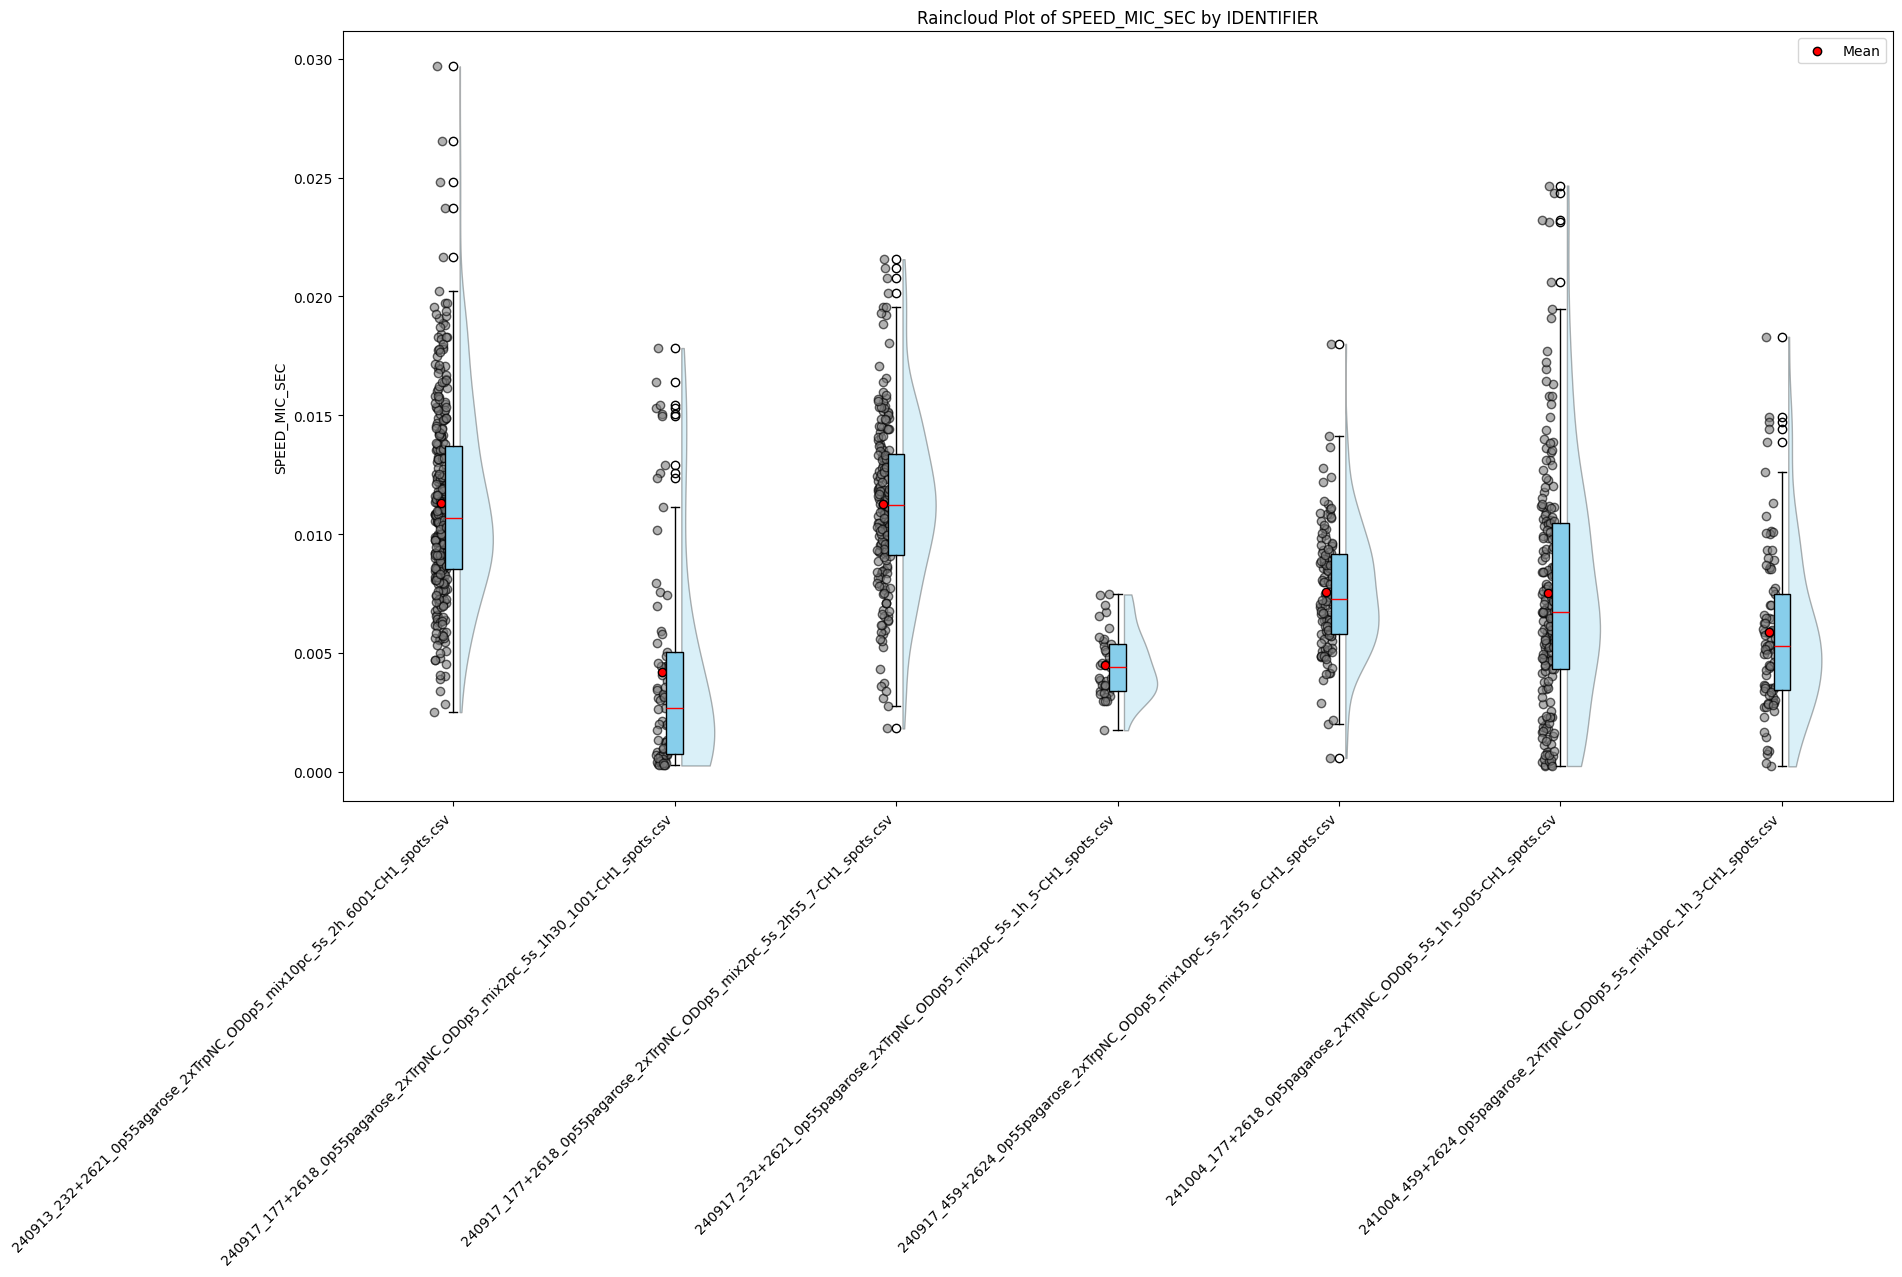

In [27]:
# Generate a raincloud plot of 'column_names'(variable of choice) against the 'IDENTIFIER'(usually strain or different codition,
# the name will be extracted from the _spots.csv file) from the loaded_combined_tracks DataFrame

tu.raincloud_plot(loaded_combined_tracks, x_col="IDENTIFIER",y_col="SPEED_MIC_SEC", save_dir= folder_manager.tracksanalysisdir, show_outliers=True, save_plot=False)

# Contact reversals analysis

In [28]:
## Compute Contact Reversals (CR) and save csv file for manual correction

# Load data
spots_tables = spots_dataframes
segmented_images = omnu.import_image_or_video(folder_manager.segmentdir)

# Initialize a list to collect all dataframes
all_contact_reversals = []

for key, spots_table in spots_tables.items():

    # Classify tracks before computing reversals
    spots_table_classified, subtracks_table = tu.tracks_classification(spots_table, displacement_threshold=5*pixel_scale)
    spots_table_classified.to_csv(folder_manager.tracksanalysisdir + '/' + key + '/' + f"{key}_spots_classified-1.csv", index=False) 
    
    # Search neighbouring cells for tracks with at least 3 consecutive moving frames (defined based on a displacement threshold)
    segmented_image = segmented_images[key + '_segmented.tif']  # Important: the same key from spots_tables is used to get the corresponding segmented image
    subtracks_neighbours = tu.find_neighbours(subtracks_table, segmented_image, pixel_scale) 
    subtracks_neighbours = tu.find_contact_and_measure_angle(subtracks_neighbours, segmented_image)
    subtracks_neighbours.to_csv(folder_manager.tracksanalysisdir + '/' + key + '/' + f"{key}_spots_with_neighbours-2.csv", index=False)

    # Compute reversals for the current spot table
    subtracks_reversals = tu.compute_reversals(subtracks_neighbours)
    subtracks_reversals.to_csv(folder_manager.tracksanalysisdir + '/' + key + '/' + f"{key}_spots_with_reversals-3.csv", index=False)

    # Determine whether there are contact reversals
    subtracks_contact_reversals = tu.find_contact_reversals(subtracks_reversals)
    subtracks_contact_reversals.to_csv(folder_manager.tracksanalysisdir + '/' + key + '/' + f"{key}_spots_with_contact_reversals-4.csv", index=False)

    # Add the current dataframe to the list for combined plotting
    all_contact_reversals.append(subtracks_contact_reversals)

# Combine all dataframes into one
##combined_contact_reversals = pd.concat(all_contact_reversals, ignore_index=True)



In [29]:
## Process 'corrected' files to plot CR

#INPUT USER: Gather corrected files in one directory------------------
folder_path_corrected = "/Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/tracks_analysis/corrected_files/"
file_path = "/Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir"
#---------------------------------------------------------------------

summary_data_path = file_path + "/summary_data/"
os.makedirs(summary_data_path, exist_ok=True)

# Load data
spots_tables = spots_dataframes
corrected_spots_tables = tu.load_corrected_files(folder_path_corrected)
segmented_images = omnu.import_image_or_video(folder_manager.segmentdir)

# Initialize an empty DataFrame to collect all dataframes
all_contact_reversals = pd.DataFrame()

for key, corrected_spots_table in corrected_spots_tables.items():
    segmented_image = segmented_images[key[:-45] + '_segmented.tif'] 
    df_with_corrected_angles = tu.compute_corrected_contact_angle(corrected_spots_table, segmented_image)
    df_with_corrected_angles = tu.rescale_angle(df_with_corrected_angles)  # rescale between 0° and 90°
    df_with_corrected_angles.to_csv(folder_manager.tracksanalysisdir + '/' + key[:-45] + '/' + f"{key[:-45]}_spots_with_corrected_angles-5.csv", index=False)

    # Add the 'FILE' column to store the corresponding key
    df_with_corrected_angles['FILE'] = key[:-45]
    
    # Append the current dataframe to the combined dataframe
    all_contact_reversals = pd.concat([all_contact_reversals, df_with_corrected_angles], ignore_index=True)
    
    # Summary of the file
    summary_df = tu.save_contact_reversals_data(df_with_corrected_angles, key[:-45], frame_interval)
    print(folder_manager.tracksanalysisdir + '/' + key[:-45] + '/' + f"{key}_summary_contact_reversals-6.csv")
    summary_df.to_csv(folder_manager.tracksanalysisdir + '/' + key[:-45] + '/' + f"{key[:-45]}_summary_contact_reversals-6.csv", index=False)
    summary_df.to_csv(summary_data_path + f"{key[:-45]}_summary_contact_reversals-6.csv", index=False)

# Save the combined dataframe with the 'FILE' column
all_contact_reversals.to_csv(folder_manager.tracksanalysisdir + '/combined_contact_reversals.csv', index=False)

# Plot
tu.plot_contact_reversals(all_contact_reversals, '', save_dir=folder_path_corrected, bin_size=5)

# Summary of the data
summary_df = tu.save_contact_reversals_data(all_contact_reversals, 'global', frame_interval)
summary_df.to_csv(folder_path_corrected + '/summary_contact_reversals-6.csv', index=False)



Successfully loaded: /Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/tracks_analysis/corrected_files/240913_232+2621_0p55agarose_2xTrpNC_OD0p5_mix10pc_5s_2h_6001-CH1_spots_with_contact_reversals-4-corrected.csv
Successfully loaded: /Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/tracks_analysis/corrected_files/240917_459+2624_0p55pagarose_2xTrpNC_OD0p5_mix10pc_5s_2h55_6-CH1_spots_with_contact_reversals-4-corrected.csv
Successfully loaded: /Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/tracks_analysis/corrected_files/240917_177+2618_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h30_1001-CH1_spots_with_contact_reversals-4-corrected.csv
Successfully loaded: /Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/tracks_analysis/corrected_files/240917_177+2618_0p55pagarose_2xT

2026-05-28 15:46:38,091 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-28 15:46:38,092 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-28 15:46:38,093 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-05-28 15:46:38,094 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


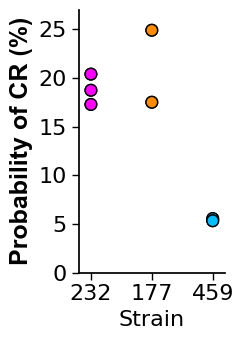

/Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/summary_data/240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h_5-CH1_summary_contact_reversals-6.csv
/Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/summary_data/240917_232+2621_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_1h_5-CH1_SC10pc_summary_contact_reversals-6.csv
/Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/summary_data/240917_177+2618_0p55pagarose_2xTrpNC_OD0p5_mix2pc_5s_2h55_7-CH1_summary_contact_reversals-6.csv
/Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/summary_data/241004_459+2624_0p5pagarose_2xTrpNC_OD0p5_5s_mix10pc_1h_3-CH1_summary_contact_reversals-6.csv
/Users/laureleblanc/Desktop/Collective-twitching-2026/3_trajectory_analysis/contact_reversals/working-dir/summary_data/240917_459+2624_0p55

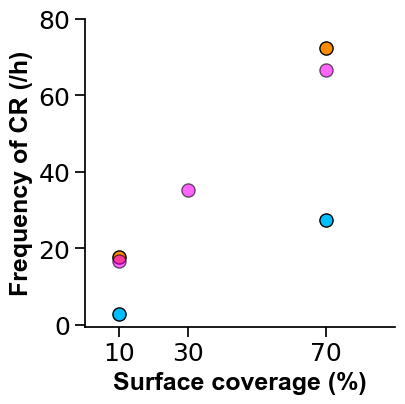

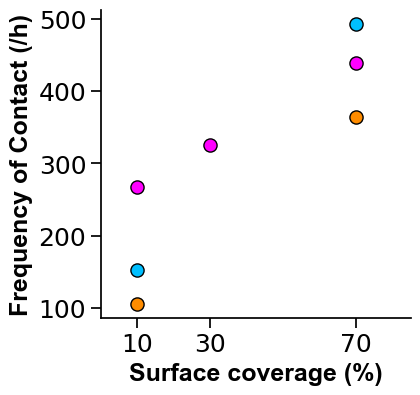

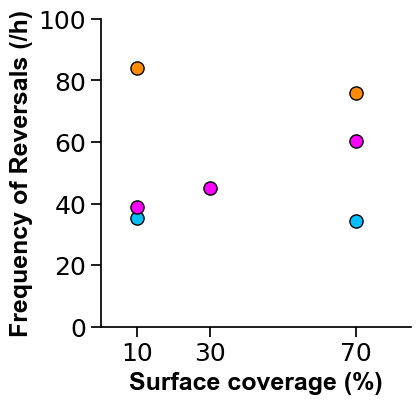

In [30]:
# Plot summary 

# INPUT USER: MANUALLY add "_SCxxpc_" in the filenames in "summary_data_path"

tu.plot_probability_of_contact_reversals(summary_data_path)
tu.plot_frequency_function_of_SC(summary_data_path)